# Phase 2: Segmentation via Clustering

Home Credit Default Risk, KDD Phase 2.

What this notebook does:
1. Reduce dimensions with PCA so distance behaves well, then run K-Means and hierarchical clustering in that space.
2. Pick the number of segments K using the elbow method and the silhouette score.
3. Run DBSCAN in a UMAP space to find density pockets and outliers.
4. Profile each cluster, give it a business name, and save the naming so later phases can read it.

Input: `datasets/final/features_clustering.csv` (the output of Phase 1).

Outputs land in `results/phase2_clustering/`: the PCA variance table and plot, the K-selection table and elbow plot, cluster labels, the cluster scatter and dendrogram images, the cluster profiles, and `cluster_names.csv`. The written report lives in the project-root `REPORT.md`, not in this notebook.

## 1. Setup and load data

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.neighbors import NearestNeighbors
import umap   # DBSCAN dijalankan di ruang UMAP (lihat Seksi 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
INPUT_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
OUT_DIR = PROJECT_ROOT / 'results/phase2_clustering'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
K_OPTIMAL = 5
N_PCA_CLUSTER = 10   # practical ceiling for a distance-based method

print(f'Project root: {PROJECT_ROOT}')
print(f'Output dir  : {OUT_DIR}')

df = pd.read_csv(INPUT_PATH)
print(f'\nLoaded features_clustering: {df.shape[0]:,} rows x {df.shape[1]:,} cols')
df.head()

Project root: C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk
Output dir  : C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering



Loaded features_clustering: 356,255 rows x 50 cols


,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,CREDIT_TERM_MONTHS,YEARS_BIRTH,YEARS_EMPLOYED,FLAG_SENTINEL_EMPLOYED,...,POS_MONTHS_COUNT,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_SK_DPD_MEAN,CC_AMT_BALANCE_MEAN,CC_MONTHS_COUNT,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE_FREQ,ORGANIZATION_TYPE_FREQ,DEF_30_CNT_SOCIAL_CIRCLE_BIN
0,100002,0.636593,-0.188553,0.067292,-0.719532,-0.644820,-0.583930,-1.510866,-0.579884,0,...,-0.369704,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944,-0.586459,0.945510,1.371072,4.626593
1,100003,1.241984,1.435749,0.746258,0.373208,-0.532854,1.957541,0.166150,-0.337531,0,...,0.001164,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944,1.695881,-1.717301,-0.887960,-0.338687
2,100004,-1.675286,-1.736026,-2.324243,-0.722630,-0.885155,-0.129067,0.689874,-0.761099,0,...,-0.987817,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944,-0.586459,0.945510,-0.872715,-0.338687
3,100006,-0.216655,-0.557173,0.406269,-0.598481,0.425995,-1.345908,0.680460,0.476617,0,...,-0.287289,-0.407481,-0.468926,-0.115527,-0.323456,-0.193504,-0.586459,0.945510,1.371072,-0.338687
4,100007,-0.438372,0.137704,-0.157464,0.149965,-0.010731,0.315863,0.893302,0.476177,0,...,1.567052,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944,-0.586459,0.945510,-1.245204,-0.338687


## 2. PCA as a compact clustering space

K-Means and Ward use Euclidean distance, so correlated and noisy axes can
dilute useful structure. PCA rotates the robustly bounded, standardized
feature matrix into orthogonal directions. Ten components are the
compact primary view; they do **not** satisfy an arbitrary 80%-variance
rule. The notebook reports the actual retained variance and compares the
five-cluster labels against the 80%, 90%, and full-dimensional solutions
using adjusted Rand index, separation, and cluster balance. Business
explanations are calculated back on readable features, not PCA values.


In [ ]:
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    calinski_harabasz_score, davies_bouldin_score,
)

feature_cols = [c for c in df.columns if c != 'SK_ID_CURR']
X = df[feature_cols].values.astype(np.float32)
print(f'Feature matrix X: {X.shape}')

pca_full = PCA(n_components=min(50, X.shape[1]), random_state=RANDOM_SEED)
X_pca50 = pca_full.fit_transform(X)

cumvar = pca_full.explained_variance_ratio_.cumsum()
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_80 = int(np.argmax(cumvar >= 0.80)) + 1
pc11_share = pca_full.explained_variance_ratio_[10] if len(cumvar) > 10 else np.nan
print(f'\nComponents for 80% variance: {n_80}')
print(f'Components for 90% variance: {n_90}')
print(f'\nPrimary clustering space: PC1-PC{N_PCA_CLUSTER} '
      f'({cumvar[N_PCA_CLUSTER-1]*100:.1f}% variance)')
print(f'PC11 itself contributes {pc11_share*100:.2f}% variance. Ten PCs are not an '
      '80%-variance rule; they are the compact primary view, validated below against '
      'the 80%, 90%, and full-dimensional solutions.')

X_cluster = X_pca50[:, :N_PCA_CLUSTER]
X_2d = X_pca50[:, :2]

variance_df = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_variance': cumvar,
})
variance_df.to_csv(OUT_DIR / 'pca_variance.csv', index=False)
print(f'\nSaved {OUT_DIR / "pca_variance.csv"}')


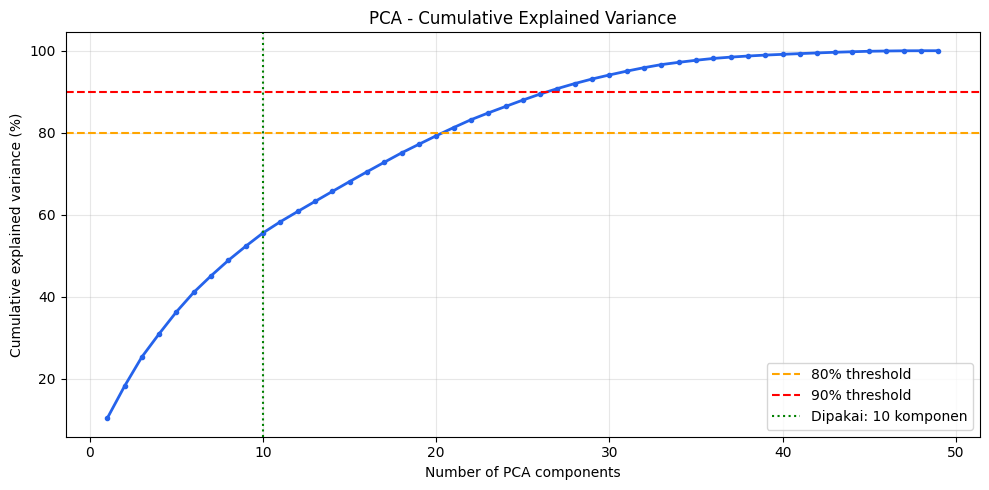

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar*100, marker='o', markersize=3, linewidth=2, color='#2563EB')
ax.axhline(80, color='orange', ls='--', label='80% threshold')
ax.axhline(90, color='red', ls='--', label='90% threshold')
ax.axvline(N_PCA_CLUSTER, color='green', ls=':', label=f'Dipakai: {N_PCA_CLUSTER} komponen')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA - Cumulative Explained Variance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_variance_plot.png', dpi=150)
plt.show()

## 3. Choosing a defensible business resolution

K from 2 to 10 is compared on a reproducible 30,000-row sample. The
normalized elbow, silhouette, Calinski-Harabasz, Davies-Bouldin, smallest
segment share, and seed stability are all exported. K=2 is allowed to be
the cleanest coarse split; K=5 is retained only if it remains near the
elbow, stable across seeds, and adds distinct, non-trivial portfolio
profiles. This is a documented business-granularity choice, not a claim
that five maximizes every geometric index.


In [ ]:
K_RANGE = range(2, 11)
SAMPLE_SIZE = 30000
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(X_cluster), size=SAMPLE_SIZE, replace=False)
X_sample = X_cluster[sample_idx]

k_results = []
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_sample)
    metric_idx = rng.choice(len(X_sample), size=5000, replace=False)
    metric_x = X_sample[metric_idx]
    metric_labels = labels[metric_idx]
    shares = np.bincount(labels, minlength=k) / len(labels)
    k_results.append({
        'k': k, 'inertia': km.inertia_,
        'silhouette': silhouette_score(metric_x, metric_labels),
        'calinski_harabasz': calinski_harabasz_score(metric_x, metric_labels),
        'davies_bouldin': davies_bouldin_score(metric_x, metric_labels),
        'min_cluster_share': shares.min(), 'max_cluster_share': shares.max(),
        'time_s': round(time.time()-t0, 2),
    })
    print(f'  K={k:2d} | inertia={km.inertia_:12.1f} | '
          f'sil={k_results[-1]["silhouette"]:.4f} | min share={shares.min():.2%}')

k_df = pd.DataFrame(k_results)
k_df.to_csv(OUT_DIR / 'k_selection.csv', index=False)

# Seed stability at the chosen business resolution.
seed_labels = []
for seed in [42, 52, 62]:
    seed_labels.append(KMeans(
        n_clusters=K_OPTIMAL, n_init=20, max_iter=300, random_state=seed
    ).fit_predict(X_sample))
stability_rows = []
for i in range(len(seed_labels)):
    for j in range(i + 1, len(seed_labels)):
        stability_rows.append({
            'seed_a': [42, 52, 62][i], 'seed_b': [42, 52, 62][j],
            'adjusted_rand_index': adjusted_rand_score(seed_labels[i], seed_labels[j]),
        })
pd.DataFrame(stability_rows).to_csv(OUT_DIR / 'k_stability.csv', index=False)

# Sensitivity to the number of retained principal directions.  This fixes
# the earlier rationale error: PC11 adds its own variance; the decision for
# 10 PCs is accepted only if labels stay close to 80%/90%/full solutions.
dimension_candidates = sorted(set([N_PCA_CLUSTER, n_80, n_90, X.shape[1]]))
dimension_rows = []
dimension_labels = {}
for n_components in dimension_candidates:
    xd = X_pca50[sample_idx, :n_components]
    km_d = KMeans(n_clusters=K_OPTIMAL, n_init=20, max_iter=300, random_state=RANDOM_SEED)
    lbl_d = km_d.fit_predict(xd)
    dimension_labels[n_components] = lbl_d
    shares = np.bincount(lbl_d, minlength=K_OPTIMAL) / len(lbl_d)
    metric_idx = rng.choice(len(xd), size=5000, replace=False)
    dimension_rows.append({
        'n_components': n_components,
        'retained_variance': cumvar[n_components-1],
        'silhouette': silhouette_score(xd[metric_idx], lbl_d[metric_idx]),
        'min_cluster_share': shares.min(), 'max_cluster_share': shares.max(),
    })
reference = dimension_labels[N_PCA_CLUSTER]
for row in dimension_rows:
    row['ari_vs_10pc'] = adjusted_rand_score(reference, dimension_labels[row['n_components']])
pd.DataFrame(dimension_rows).to_csv(OUT_DIR / 'pca_cluster_sensitivity.csv', index=False)
k_df


In [ ]:
# Normalize both axes before measuring distance to the end-point chord;
# otherwise inertia units dominate K units.  The determinant below is the
# 2-D cross-product magnitude without NumPy's deprecated vector shortcut.
x_norm = (k_df['k'].to_numpy() - k_df['k'].min()) / (k_df['k'].max() - k_df['k'].min())
y_raw = k_df['inertia'].to_numpy()
y_norm = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min())
chord = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
points = np.column_stack([x_norm - x_norm[0], y_norm - y_norm[0]])
dists = np.abs(chord[0] * points[:, 1] - chord[1] * points[:, 0]) / np.linalg.norm(chord)
elbow_k = int(k_df.iloc[int(np.argmax(dists))]['k'])
best_sil_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])
chosen = k_df.loc[k_df['k'].eq(K_OPTIMAL)].iloc[0]
stability_mean = pd.read_csv(OUT_DIR / 'k_stability.csv')['adjusted_rand_index'].mean()
print(f'Elbow Method     -> K = {elbow_k}')
print(f'Silhouette Score -> K = {best_sil_k}')
print(f'\nSelected business resolution: K = {K_OPTIMAL}')
print(f'  K=2 is the strongest coarse split; K={K_OPTIMAL} is retained because it is '
      f'near the elbow, keeps the smallest segment at {chosen.min_cluster_share:.1%}, '
      f'and is seed-stable (mean ARI={stability_mean:.3f}).')
print('  The dashboard therefore calls these portfolio segments, not risk classes.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_df['k'], k_df['inertia'], 'o-', color='#2563EB', linewidth=2)
axes[0].scatter([elbow_k], [k_df.loc[k_df['k']==elbow_k, 'inertia'].iloc[0]],
                s=150, color='red', zorder=5, label=f'Elbow → K={elbow_k}')
axes[0].axvline(K_OPTIMAL, color='green', ls='--', alpha=.65, label=f'Selected K={K_OPTIMAL}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow and selected resolution'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(k_df['k'], k_df['silhouette'], 'o-', color='#059669', linewidth=2)
axes[1].scatter([best_sil_k], [k_df.loc[k_df['k']==best_sil_k, 'silhouette'].iloc[0]],
                s=150, color='red', zorder=5, label=f'Best coarse split → K={best_sil_k}')
axes[1].axvline(K_OPTIMAL, color='green', ls='--', alpha=.65, label=f'Selected K={K_OPTIMAL}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Separation versus business granularity'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT_DIR / 'elbow_plot.png', dpi=160, bbox_inches='tight'); plt.show()


## 4. K-Means on all 356K applicants

In [6]:
print('Running K-Means (K=5) on full data ...')
t0 = time.time()
kmeans = KMeans(n_clusters=K_OPTIMAL, n_init=10, max_iter=300, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_cluster)
print(f'  Done in {time.time()-t0:.1f}s | Inertia = {kmeans.inertia_:.1f}')

rng2 = np.random.default_rng(RANDOM_SEED)
sil_idx = rng2.choice(len(X_cluster), size=10000, replace=False)
sil_kmeans = silhouette_score(X_cluster[sil_idx], kmeans_labels[sil_idx])
print(f'  Silhouette Score (sample 10K): {sil_kmeans:.4f}')

unique, counts = np.unique(kmeans_labels, return_counts=True)
print(f'\nDistribusi cluster K-Means:')
for cid, cnt in zip(unique, counts):
    pct = cnt/len(kmeans_labels)*100
    print(f'  Cluster {cid}: {cnt:>7,} rows ({pct:5.1f}%) {"█"*int(pct/2)}')

Running K-Means (K=5) on full data ...


  Done in 6.1s | Inertia = 5397019.0


  Silhouette Score (sample 10K): 0.1413

Distribusi cluster K-Means:
  Cluster 0:  54,535 rows ( 15.3%) ███████
  Cluster 1:   7,637 rows (  2.1%) █
  Cluster 2: 121,820 rows ( 34.2%) █████████████████
  Cluster 3: 119,937 rows ( 33.7%) ████████████████
  Cluster 4:  52,326 rows ( 14.7%) ███████


## 5. Exploratory DBSCAN density view

DBSCAN asks a different question from K-Means: which sampled points lack
a sufficiently dense local neighbourhood? It runs on a reproducible
50,000-row UMAP projection and chooses `eps` from a normalized k-distance
knee. UMAP is useful for a readable local-neighbourhood map, but it can
distort global distance and density. The sample is therefore checked
against portfolio feature means, and DBSCAN noise is carried forward as
exploratory corroboration only—not as default, fraud, or a full-portfolio
cluster label.


In [ ]:
# DBSCAN is an exploratory density view on a reproducible random sample.
# UMAP makes the neighbourhood structure visible, but can distort global
# distance; noise is therefore a review signal, never a default/fraud label.
DBSCAN_SAMPLE = 50000
MIN_SAMPLES = 15

rng3 = np.random.default_rng(RANDOM_SEED)
dbscan_idx = rng3.choice(len(X), size=DBSCAN_SAMPLE, replace=False)
X_db_raw = X[dbscan_idx]

representativeness = pd.DataFrame({
    'feature': feature_cols,
    'portfolio_mean': X.mean(axis=0),
    'sample_mean': X_db_raw.mean(axis=0),
})
representativeness['abs_mean_gap'] = (
    representativeness['sample_mean'] - representativeness['portfolio_mean']).abs()
representativeness.to_csv(OUT_DIR / 'dbscan_sample_validation.csv', index=False)

print(f'Step 1 - UMAP embedding {DBSCAN_SAMPLE:,} x {X_db_raw.shape[1]} features -> 2D ...')
t0 = time.time()
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0,
                    metric='euclidean', random_state=RANDOM_SEED)
X_umap = reducer.fit_transform(X_db_raw)
print(f'  Done in {time.time()-t0:.1f}s')

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_umap)
kdist = np.sort(nn.kneighbors(X_umap)[0][:, -1])
xx = np.linspace(0, 1, len(kdist))
yy = (kdist - kdist.min()) / max(kdist.max() - kdist.min(), 1e-12)
chord = np.array([1.0, yy[-1] - yy[0]])
points = np.column_stack([xx, yy - yy[0]])
dline = np.abs(chord[0] * points[:, 1] - chord[1] * points[:, 0]) / np.linalg.norm(chord)
EPS = float(round(kdist[int(np.argmax(dline))], 3))
print(f'  eps (normalized k-distance knee, k={MIN_SAMPLES}) = {EPS}')

print(f'Step 2 - DBSCAN in UMAP space (eps={EPS}, min_samples={MIN_SAMPLES}) ...')
t0 = time.time()
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_umap)
print(f'  Done in {time.time()-t0:.1f}s')
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = int(np.sum(dbscan_labels == -1))
pct_out = n_outliers / len(dbscan_labels) * 100
print(f'  Density pockets found: {n_clusters_db}')
print(f'  Noise (label -1): {n_outliers:,} ({pct_out:.1f}%)')


## 6. Sampled Ward structural benchmark

Exact Ward clustering needs quadratic memory and is infeasible for
356,255 rows. The notebook fits Ward on a seeded 10,000-row sample, forms
sample-cluster centres, and assigns the full portfolio to the nearest
centre. This is an explicit approximation, not full-data hierarchical
clustering. Adjusted Rand index and normalized mutual information quantify
agreement with K-Means; a dendrogram remains a sample-level visual check.


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist

# Ward requires O(n^2) memory, so this is explicitly a sampled structural
# benchmark: fit Ward on 10K rows, form sample-cluster centres, and assign
# the full portfolio to the nearest centre. It is not exact full-data Ward.
HIER_SAMPLE = 10000
rng_h = np.random.default_rng(RANDOM_SEED)
hidx = rng_h.choice(len(X_cluster), size=HIER_SAMPLE, replace=False)
X_h = X_cluster[hidx]
print(f'Step 1 - Ward agglomerative benchmark on {HIER_SAMPLE:,} rows ...')
t0 = time.time()
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
sample_labels = agglo.fit_predict(X_h)
print(f'  Done in {time.time()-t0:.1f}s')
centroids = np.vstack([X_h[sample_labels == c].mean(axis=0) for c in range(K_OPTIMAL)])
print('Step 2 - Assign all rows to the nearest sampled-Ward centre ...')
hier_labels = cdist(X_cluster, centroids).argmin(axis=1).astype(np.int32)

method_agreement = pd.DataFrame([{
    'comparison': 'K-Means vs sampled Ward nearest-centre assignment',
    'adjusted_rand_index': adjusted_rand_score(kmeans_labels, hier_labels),
    'normalized_mutual_information': normalized_mutual_info_score(kmeans_labels, hier_labels),
}])
method_agreement.to_csv(OUT_DIR / 'method_agreement.csv', index=False)
print(method_agreement.to_string(index=False))

DENDRO_N = 2000
didx = rng_h.choice(len(X_h), size=min(DENDRO_N, len(X_h)), replace=False)
subcenters = X_h[didx]
linkage_methods = ['ward', 'complete', 'average']
linkage_results = {method: linkage(subcenters, method=method) for method in linkage_methods}

u_h, c_h = np.unique(hier_labels, return_counts=True)
print('\nSampled-Ward assignment distribution:')
for cid, cnt in zip(u_h, c_h):
    print(f'  Cluster {cid}: {cnt:>7,} rows ({cnt/len(hier_labels):5.1%})')


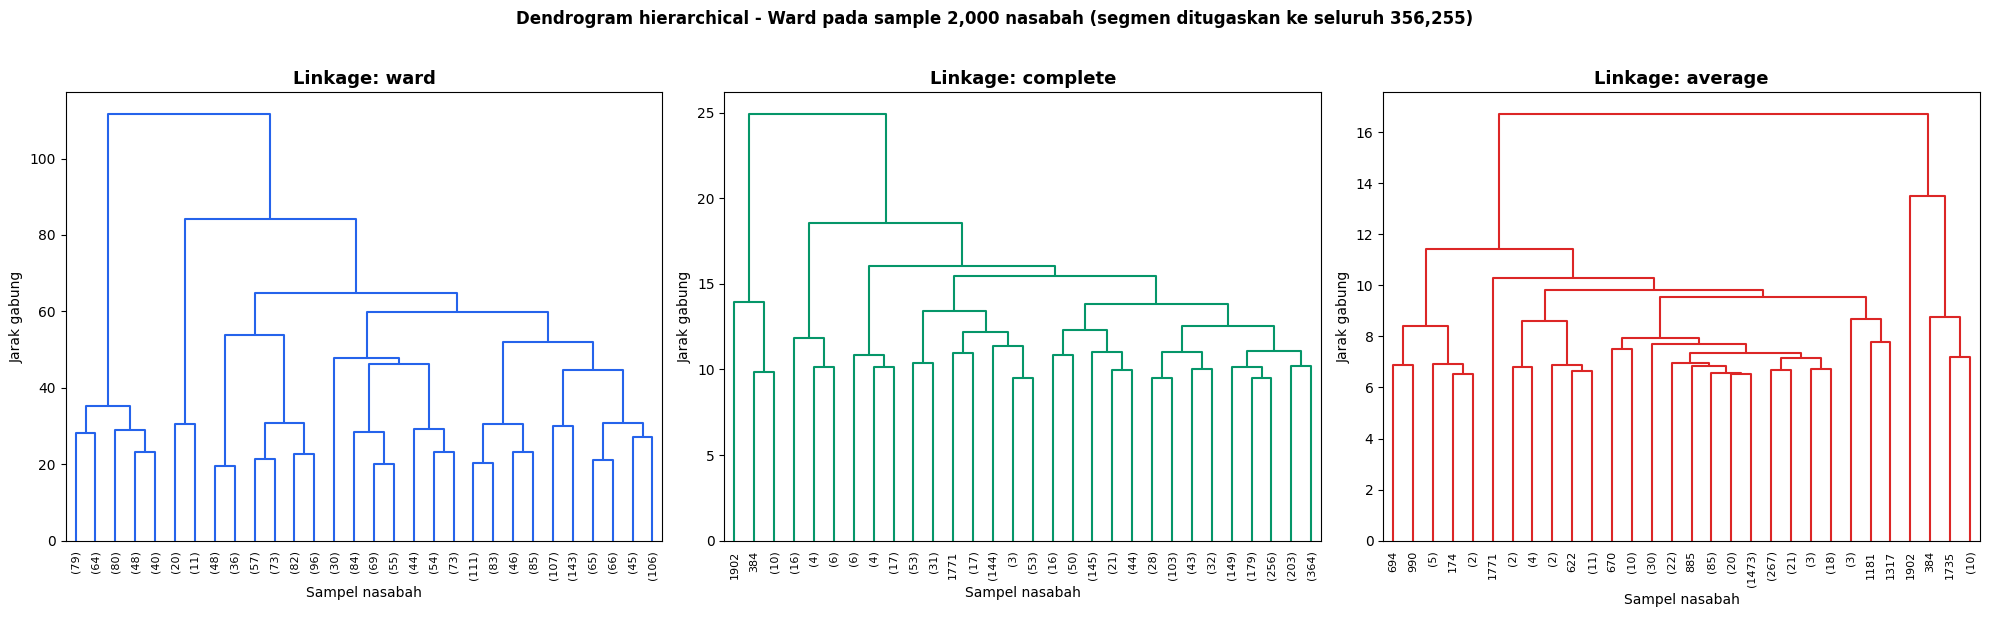

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2563EB', '#059669', '#DC2626']
for ax, method, color in zip(axes, linkage_methods, colors):
    dendrogram(linkage_results[method], ax=ax, truncate_mode='lastp', p=30,
               show_leaf_counts=True, leaf_rotation=90, leaf_font_size=8,
               color_threshold=0, above_threshold_color=color)
    ax.set_title(f'Linkage: {method}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sampel nasabah'); ax.set_ylabel('Jarak gabung')
plt.suptitle(f'Dendrogram hierarchical - Ward pada sample {len(subcenters):,} nasabah (segmen ditugaskan ke seluruh {len(X_cluster):,})',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cluster maps in 2D

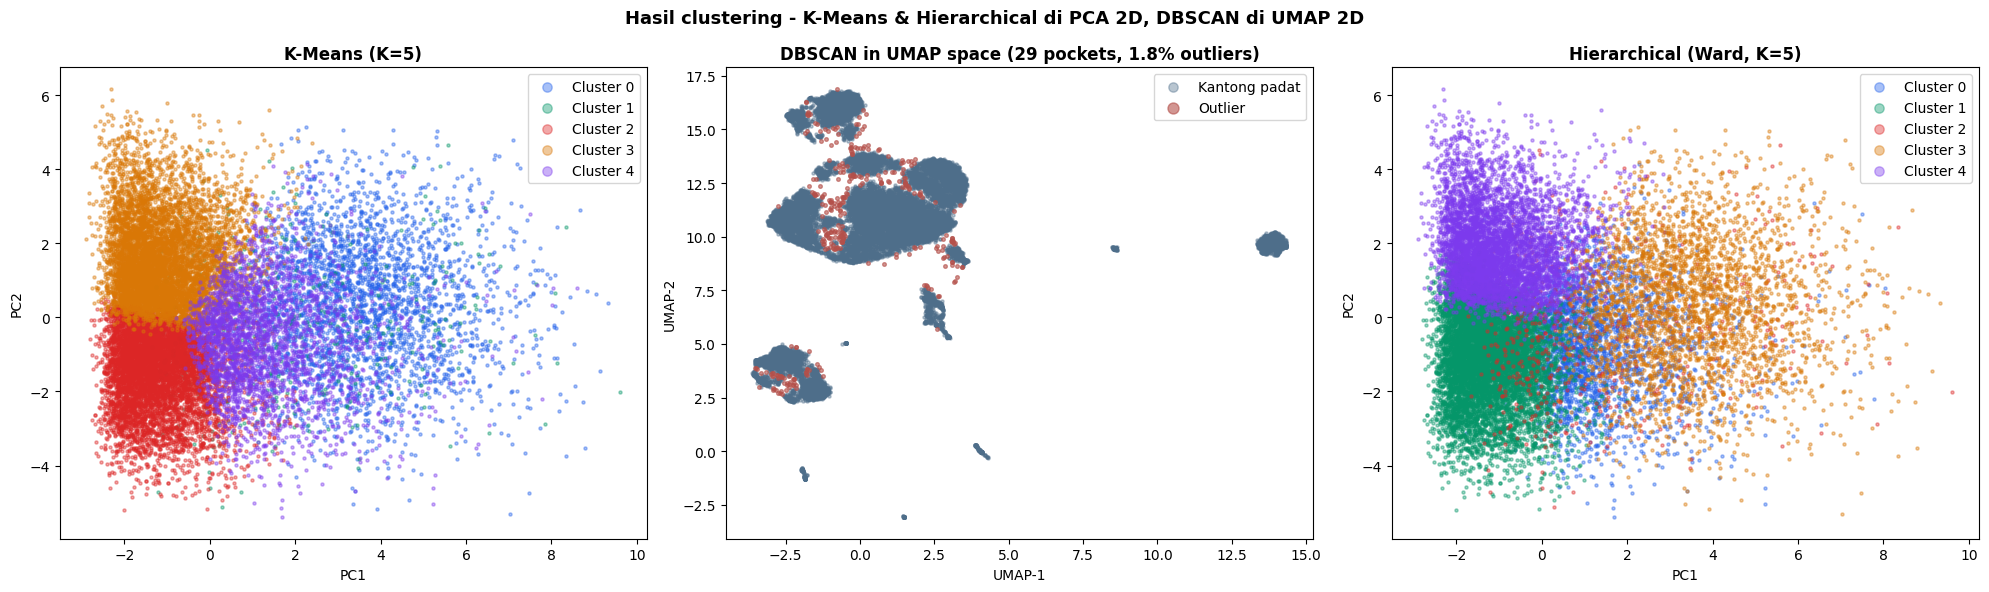

In [10]:
VIZ = 20000
rng4 = np.random.default_rng(RANDOM_SEED)
viz_idx = rng4.choice(len(X_2d), size=VIZ, replace=False)
COLORS = ['#2563EB', '#059669', '#DC2626', '#D97706', '#7C3AED']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for cid in range(K_OPTIMAL):
    mask = kmeans_labels[viz_idx] == cid
    axes[0].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[0].set_title(f'K-Means (K={K_OPTIMAL})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

viz_db_n = min(VIZ, len(dbscan_idx))
db_lbl = dbscan_labels[:viz_db_n]
noise_mask = db_lbl == -1
axes[1].scatter(X_umap[:viz_db_n][~noise_mask, 0], X_umap[:viz_db_n][~noise_mask, 1],
                c='#4E6E8A', label='Kantong padat', alpha=0.4, s=5)
axes[1].scatter(X_umap[:viz_db_n][noise_mask, 0], X_umap[:viz_db_n][noise_mask, 1],
                c='#B4504A', label='Outlier', alpha=0.6, s=7)
axes[1].set_title(f'DBSCAN in UMAP space ({n_clusters_db} pockets, {pct_out:.1f}% outliers)', fontweight='bold')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].legend(markerscale=3)

for cid in range(K_OPTIMAL):
    mask = hier_labels[viz_idx] == cid
    axes[2].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[2].set_title(f'Hierarchical (Ward, K={K_OPTIMAL})', fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=3)

plt.suptitle('Hasil clustering - K-Means & Hierarchical di PCA 2D, DBSCAN di UMAP 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cluster_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save the cluster labels

In [ ]:
labels_df = pd.DataFrame({
    'ROW_ID': np.arange(len(X_cluster)),
    'CLUSTER_KMEANS': kmeans_labels,
    'CLUSTER_HIER': hier_labels,
})
if 'SK_ID_CURR' in df.columns:
    labels_df.insert(1, 'SK_ID_CURR', df['SK_ID_CURR'].values)
labels_df['CLUSTER_DBSCAN'] = np.nan
labels_df.loc[dbscan_idx, 'CLUSTER_DBSCAN'] = dbscan_labels.astype(float)
labels_df['IS_OUTLIER'] = (labels_df['CLUSTER_DBSCAN'] == -1).astype('Int8')

def write_csv_atomic(frame, path):
    # Write beside the target, then atomically replace it. This avoids a
    # Windows failure seen when pandas truncates an existing dashboard
    # artefact while a filesystem indexer briefly holds a handle.
    path = Path(path)
    temp = path.with_name(f'.{path.stem}.tmp.csv')
    frame.to_csv(temp, index=False)
    for attempt in range(6):
        try:
            os.replace(temp, path)
            return
        except OSError:
            if attempt == 5:
                raise
            time.sleep(.5 * (attempt + 1))

write_csv_atomic(labels_df, OUT_DIR / 'cluster_labels.csv')
write_csv_atomic(labels_df, PROJECT_ROOT / 'datasets/final/cluster_labels.csv')
print('Saved cluster_labels.csv to:')
print(f'  {OUT_DIR / "cluster_labels.csv"}')
print(f'  {PROJECT_ROOT / "datasets/final/cluster_labels.csv"}  (for Phase 3 and 4)')

viz_export = pd.DataFrame({
    'PC1': X_2d[viz_idx, 0],
    'PC2': X_2d[viz_idx, 1],
    'CLUSTER_KMEANS': kmeans_labels[viz_idx],
})
write_csv_atomic(viz_export, OUT_DIR / 'cluster_viz_sample.csv')
print(f'Saved cluster_viz_sample.csv ({len(viz_export):,} rows for the dashboard)')
labels_df.head()


## 9. Cluster profiling: what makes each segment different

For every feature we take its mean per cluster and compare it to the global mean, scaled by the global standard deviation. The result reads as "standard deviations from average, times 100", so the features with the largest absolute deviation are the ones that set a cluster apart.

In [12]:
TOP_N = 10
df_prof = pd.concat([df.reset_index(drop=True), labels_df[['CLUSTER_KMEANS']].reset_index(drop=True)], axis=1)
feat_cols = [c for c in df_prof.columns if c not in ['SK_ID_CURR', 'CLUSTER_KMEANS'] and pd.api.types.is_numeric_dtype(df_prof[c])]

profiles = df_prof.groupby('CLUSTER_KMEANS')[feat_cols].mean()
global_mean = df_prof[feat_cols].mean()
global_std = df_prof[feat_cols].std().replace(0, np.nan)
rel_diff = profiles.sub(global_mean).div(global_std) * 100

profiles.to_csv(OUT_DIR / 'cluster_profiles.csv')
print(f'Saved cluster_profiles.csv ({profiles.shape[0]} clusters x {profiles.shape[1]} features)')

summary_rows = []
top_features = {}
for cid in rel_diff.index:
    row = rel_diff.loc[cid].abs().sort_values(ascending=False)
    top_cols = row.head(TOP_N).index.tolist()
    top_df = pd.DataFrame({
        'fitur': top_cols,
        'rel_diff_pct': rel_diff.loc[cid, top_cols].values,
        'arah': ['ABOVE' if v > 0 else 'BELOW' for v in rel_diff.loc[cid, top_cols].values],
    }).sort_values('rel_diff_pct', key=abs, ascending=False)
    top_features[cid] = top_df
    for _, r in top_df.iterrows():
        summary_rows.append({'cluster_id': cid, 'fitur': r['fitur'], 'rel_diff_pct': round(r['rel_diff_pct'], 2), 'arah': r['arah']})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'cluster_summary.csv', index=False)
print(f'Saved cluster_summary.csv')

for cid in sorted(top_features.keys()):
    n = (labels_df['CLUSTER_KMEANS'] == cid).sum()
    pct = n / len(labels_df) * 100
    print(f'\n{"="*70}\nCLUSTER {cid} - {n:,} applicants ({pct:.1f}%)\n{"-"*70}')
    for _, r in top_features[cid].iterrows():
        arrow = 'up' if r['arah'] == 'ABOVE' else 'down'
        print(f'  {r["fitur"]:42s} {r["rel_diff_pct"]:>+7.1f}%  {arrow} {r["arah"]}')

Saved cluster_profiles.csv (5 clusters x 49 features)
Saved cluster_summary.csv

CLUSTER 0 - 54,535 applicants (15.3%)
----------------------------------------------------------------------
  CC_UTILIZATION_MAX                          +217.4%  up ABOVE
  CC_UTILIZATION_MEAN                         +202.7%  up ABOVE
  CC_AMT_BALANCE_MEAN                         +163.8%  up ABOVE
  CC_MONTHS_COUNT                             +157.1%  up ABOVE
  INST_COUNT                                  +150.7%  up ABOVE
  PREV_COUNT                                   +48.4%  up ABOVE
  AMT_REQ_CREDIT_BUREAU_YEAR                   +46.7%  up ABOVE
  CC_SK_DPD_MEAN                               +40.7%  up ABOVE
  POS_MONTHS_COUNT                             +31.8%  up ABOVE
  NAME_CONTRACT_TYPE                           +26.0%  up ABOVE

CLUSTER 1 - 7,637 applicants (2.1%)
----------------------------------------------------------------------
  INST_DPD_MEAN                               +546.9%  up ABOV

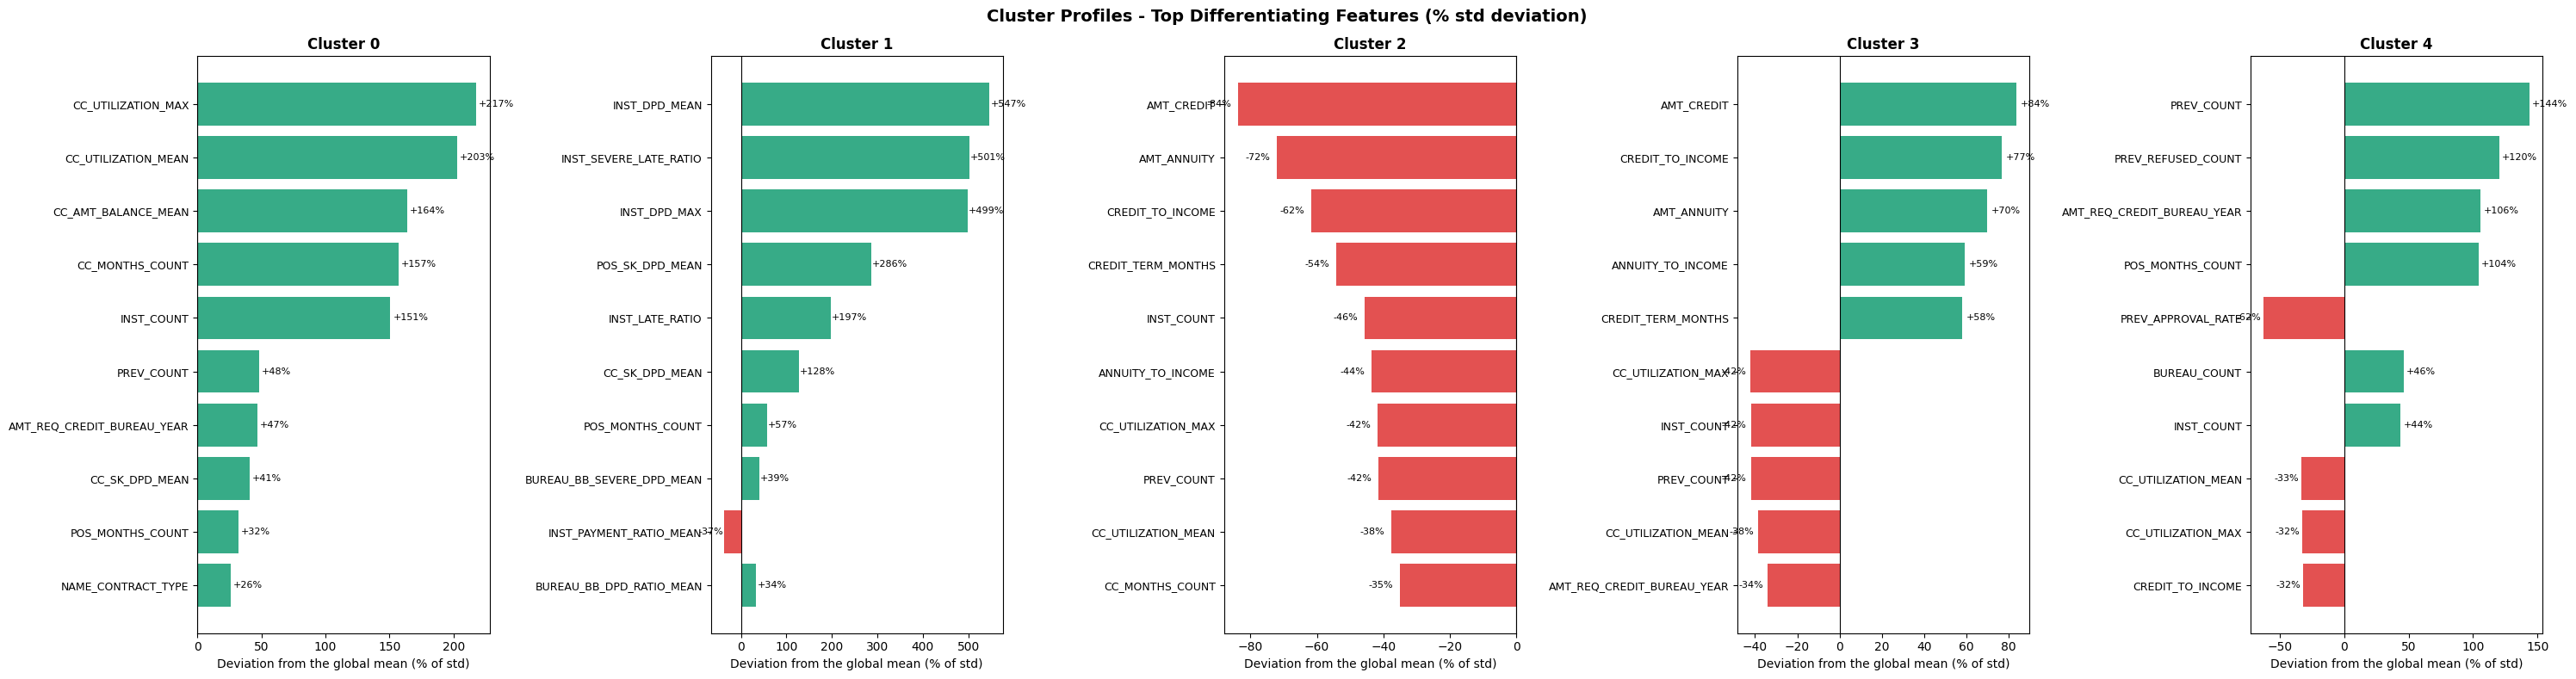

In [13]:
n_clusters = len(top_features)
fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 8))
if n_clusters == 1:
    axes = [axes]
for ax, cid in zip(axes, sorted(top_features.keys())):
    tdf = top_features[cid].head(TOP_N)
    values = tdf['rel_diff_pct'].values
    labels = tdf['fitur'].values
    colors_bar = ['#059669' if v > 0 else '#DC2626' for v in values]
    bars = ax.barh(range(len(values)), values, color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Deviation from the global mean (% of std)')
    ax.set_title(f'Cluster {cid}', fontweight='bold')
    ax.invert_yaxis()
    for bar, val in zip(bars, values):
        x = val + (2 if val >= 0 else -2)
        ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=8, ha='left' if val >= 0 else 'right')
plt.suptitle('Cluster Profiles - Top Differentiating Features (% std deviation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cluster_profile_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Business interpretation and segment naming

A human reads the top differentiating features of each cluster and gives it a business name, a risk level, and a short recommendation. The algorithm only finds the grouping; turning it into something a bank can act on is the analyst's job. The names and sizes are saved to `cluster_names.csv` so every later phase reads them rather than hard-coding a mapping that shifts between runs.

In [ ]:
# Assign one unique, descriptive name to each cluster from its dominant
# business pattern. Names describe portfolio geometry; they are not credit
# decisions and must never replace applicant-level repayment assessment.
def mean_available(frame, columns):
    cols = [c for c in columns if c in frame.columns]
    return frame[cols].mean(axis=1) if cols else pd.Series(0.0, index=frame.index)

score_table = pd.DataFrame(index=profiles.index)
score_table['repayment_stress'] = mean_available(profiles, [
    'INST_DPD_MEAN', 'INST_DPD_MAX', 'INST_LATE_RATIO',
    'INST_SEVERE_LATE_RATIO', 'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN'])
score_table['card_intensity'] = mean_available(profiles, [
    'CC_UTILIZATION_MEAN', 'CC_UTILIZATION_MAX', 'CC_AMT_BALANCE_MEAN', 'CC_MONTHS_COUNT'])
score_table['relationship_depth'] = mean_available(profiles, [
    'PREV_COUNT', 'BUREAU_COUNT', 'POS_MONTHS_COUNT', 'CC_MONTHS_COUNT'])
score_table['borrowing_scale'] = mean_available(profiles, [
    'AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_TO_INCOME'])

remaining = set(int(c) for c in profiles.index)
assignments = {}
def take_highest(score, name):
    cid = int(score.loc[list(remaining)].idxmax())
    assignments[cid] = name
    remaining.remove(cid)

take_highest(score_table['repayment_stress'], 'Repayment-Stress History')
take_highest(score_table['card_intensity'], 'Intensive Card User')
take_highest(score_table['relationship_depth'], 'History-Rich Credit User')
take_highest(score_table['borrowing_scale'], 'High-Exposure Applicant')
assignments[remaining.pop()] = 'Thin-File / Low-Intensity'

META = {
    'Repayment-Stress History': {
        'risk': 'Elevated review priority',
        'profile': 'Repayment delays are the strongest differentiating pattern.',
        'watch': 'Recency, severity, cure status, and current affordability.',
        'action': 'Prioritise a specific repayment-history and affordability review. For existing hardship, assess customer contact or restructuring under policy.'},
    'Intensive Card User': {
        'risk': 'Utilisation review',
        'profile': 'Revolving-credit use and card history dominate the segment.',
        'watch': 'Current utilisation, balances, arrears, and limit suitability.',
        'action': 'Review card balances and payment capacity before any limit change; consider consolidation support where suitable.'},
    'History-Rich Credit User': {
        'risk': 'History-rich review',
        'profile': 'Long and active internal/external credit history.',
        'watch': 'Whether old refusals or arrears remain relevant today.',
        'action': 'Reconcile prior decisions and current obligations; use the richer history to verify, not to assume, present capacity.'},
    'High-Exposure Applicant': {
        'risk': 'Affordability review',
        'profile': 'Larger requested exposure and repayment commitment.',
        'watch': 'Verified income, total obligations, and adverse-scenario affordability.',
        'action': 'Verify sustainable income and stress-test repayment capacity before changing exposure.'},
    'Thin-File / Low-Intensity': {
        'risk': 'Standard / thin-file review',
        'profile': 'Lower product intensity and a simpler credit footprint.',
        'watch': 'Information gaps and the difference between no history and good history.',
        'action': 'Use standard underwriting; where history is thin, verify with permitted alternative evidence rather than treating absence as risk.'},
}

SLUG_BY_NAME = {
    'History-Rich Credit User': 'history_rich',
    'Thin-File / Low-Intensity': 'thin_file',
    'Intensive Card User': 'card_intensive',
    'High-Exposure Applicant': 'high_exposure',
    'Repayment-Stress History': 'repayment_stress',
}
names_rows = []
for cid in sorted(assignments):
    name = assignments[cid]
    meta = META[name]
    names_rows.append({
        'cluster_id': cid,
        'nama': name,
        'slug': SLUG_BY_NAME[name],
        'profil_risiko': meta['risk'],
        'profile_summary': meta['profile'],
        'watch_items': meta['watch'],
        'recommended_action': meta['action'],
        'n_applicants': int((labels_df['CLUSTER_KMEANS'] == cid).sum()),
    })
    print(f'Cluster {cid}: {name} — {meta["risk"]}')

names_df = pd.DataFrame(names_rows)
write_csv_atomic(names_df, OUT_DIR / 'cluster_names.csv')
write_csv_atomic(names_df, PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print('\nSaved cluster_names.csv (results + datasets/final):')
print(names_df.to_string(index=False))


---
Phase 2 done. The artefacts are in `results/phase2_clustering/`, and `datasets/final/cluster_labels.csv` carries the segment assignments forward to Phase 3 and Phase 4.

---
## 11. Comparable business view and DBSCAN map

The earlier small multiples show the strongest features separately for each
cluster, but separate axes make comparison unnecessarily hard. The heatmap
below puts all five segments on one scale using six domain dimensions. Blue
means “more of the named dimension” and orange means “less”; the colours do
not mean approve or decline. A second view exposes the actual DBSCAN UMAP
map so density noise can be inspected rather than reported as a single count.


In [ ]:
import seaborn as sns

business = pd.read_csv(PROJECT_ROOT / 'datasets/final/features_business.csv')
business_labeled = business.merge(
    labels_df[['ROW_ID', 'CLUSTER_KMEANS']], on='ROW_ID', how='inner', validate='one_to_one')
NAME_BY_CID = dict(zip(names_df['cluster_id'], names_df['nama']))
business_labeled['Segment'] = business_labeled['CLUSTER_KMEANS'].map(NAME_BY_CID)

dimension_features = {
    'Repayment burden': ['ANNUITY_TO_INCOME', 'CREDIT_TO_INCOME', 'BUREAU_DEBT_TO_CREDIT_RATIO'],
    'Observed delinquency': ['INST_DPD_MAX', 'INST_LATE_RATIO', 'INST_SEVERE_LATE_RATIO',
                             'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN'],
    'Revolving intensity': ['CC_UTILIZATION_MEAN', 'CC_UTILIZATION_MAX', 'CC_AMT_BALANCE_MEAN'],
    'Credit-history depth': ['BUREAU_COUNT', 'PREV_COUNT', 'POS_MONTHS_COUNT', 'CC_MONTHS_COUNT'],
    'External-score strength': ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
    'Borrowing scale': ['AMT_CREDIT', 'AMT_ANNUITY'],
}

numeric = business_labeled.select_dtypes(include=np.number).copy()
standardized = pd.DataFrame(index=numeric.index)
for col in sorted({c for cols in dimension_features.values() for c in cols if c in numeric.columns}):
    values = numeric[col].replace([np.inf, -np.inf], np.nan)
    lo, hi = values.quantile([.01, .99])
    clipped = values.clip(lo, hi)
    std = clipped.std()
    standardized[col] = (clipped - clipped.mean()) / std if std and np.isfinite(std) else 0.0

dimensions = pd.DataFrame(index=business_labeled.index)
for dimension, columns in dimension_features.items():
    use = [c for c in columns if c in standardized.columns]
    dimensions[dimension] = standardized[use].mean(axis=1)
dimensions['CLUSTER_KMEANS'] = business_labeled['CLUSTER_KMEANS'].values
comparison = dimensions.groupby('CLUSTER_KMEANS').mean().T
comparison.columns = [NAME_BY_CID[int(c)] for c in comparison.columns]
comparison = comparison[names_df.sort_values('cluster_id')['nama'].tolist()]

comparison_long = comparison.rename_axis('business_dimension').reset_index().melt(
    id_vars='business_dimension', var_name='Segment', value_name='portfolio_sd')
comparison_long.to_csv(OUT_DIR / 'cluster_comparison_long.csv', index=False)

business_summary = business_labeled.groupby(['CLUSTER_KMEANS', 'Segment']).agg(
    applicants=('SK_ID_CURR', 'size'),
    median_income=('AMT_INCOME_TOTAL', 'median'),
    median_credit=('AMT_CREDIT', 'median'),
    median_credit_to_income=('CREDIT_TO_INCOME', 'median'),
    median_annuity_to_income=('ANNUITY_TO_INCOME', 'median'),
    median_installment_late_share=('INST_LATE_RATIO', 'median'),
    median_external_score_2=('EXT_SOURCE_2', 'median'),
    median_card_utilisation=('CC_UTILIZATION_MEAN', 'median'),
).reset_index()
business_summary.to_csv(OUT_DIR / 'cluster_business_summary.csv', index=False)
names_df[['cluster_id', 'nama', 'profile_summary', 'watch_items', 'recommended_action']].to_csv(
    OUT_DIR / 'cluster_action_matrix.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(comparison, cmap='vlag', center=0, annot=True, fmt='+.2f',
            linewidths=.6, cbar_kws={'label': 'Portfolio standard deviations'}, ax=ax)
ax.set_xlabel('Segment'); ax.set_ylabel('Business dimension')
ax.set_title('All segments on one comparable business scale', fontweight='bold')
plt.xticks(rotation=18, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_cluster_comparison.png', dpi=170, bbox_inches='tight')
plt.show()

dbscan_export = pd.DataFrame({
    'ROW_ID': dbscan_idx,
    'SK_ID_CURR': df.iloc[dbscan_idx]['SK_ID_CURR'].to_numpy(),
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'DBSCAN_LABEL': dbscan_labels,
    'IS_NOISE': (dbscan_labels == -1).astype(int),
    'CLUSTER_KMEANS': kmeans_labels[dbscan_idx],
})
dbscan_export['Segment'] = dbscan_export['CLUSTER_KMEANS'].map(NAME_BY_CID)
dbscan_export.to_csv(OUT_DIR / 'dbscan_umap_sample.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 7))
dense = dbscan_export[dbscan_export['IS_NOISE'] == 0]
noise = dbscan_export[dbscan_export['IS_NOISE'] == 1]
ax.scatter(dense['UMAP1'], dense['UMAP2'], s=5, alpha=.28, c='#4E6E8A',
           label=f'Density pockets ({len(dense):,})')
ax.scatter(noise['UMAP1'], noise['UMAP2'], s=14, alpha=.85, c='#B4504A',
           edgecolors='white', linewidths=.15, label=f'Noise for review ({len(noise):,})')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('DBSCAN density map: isolated points are review signals, not defaults', fontweight='bold')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_dbscan_umap.png', dpi=170, bbox_inches='tight')
plt.show()

print(f'Saved comparable cluster view, business medians, action matrix, and {len(dbscan_export):,}-row DBSCAN map.')
